In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
from scipy.stats import norm, t
import matplotlib.pyplot as plt

In [ ]:
stockList = ['MSFT', 'AAPL', 'NVDA', 'AMZN', 'META', 'GOOGL']
stocks = [stock for stock in stockList]

In [3]:
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=20)
stockData = yf.download(stocks, start=startDate, end=endDate)

[**********************83%***************        ]  5 of 6 completed


In [4]:
stockData.tail(10)

Price            Close                                                  \
Ticker            AAPL        AMZN       GOOGL        META        MSFT   
Date                                                                     
2026-06-26  283.779999  232.690002  337.390015  550.250000  372.970001   
2026-06-29  281.739990  240.139999  353.649994  562.599976  368.570007   
2026-06-30  289.359985  238.339996  357.369995  563.289978  373.019989   
2026-07-01  294.380005  241.699997  361.209991  612.909973  384.279999   
2026-07-02  308.630005  242.669998  359.910004  582.900024  390.489990   
2026-07-06  312.660004  244.160004  366.459991  600.289978  386.739990   
2026-07-07  310.660004  245.979996  367.029999  615.580017  388.839996   
2026-07-08  313.390015  243.619995  361.920013  603.119995  383.339996   
2026-07-09  316.220001  247.039993  358.890015  631.479980  384.359985   
2026-07-10  315.320007  245.339996  357.179993  669.210022  385.100006   

Price                         High                                      ...  \
Ticker            NVDA        AAPL        AMZN       GOOGL        META  ...   
Date                                                                    ...   
2026-06-26  192.529999  285.950012  233.899994  346.359985  556.849976  ...   
2026-06-29  194.970001  288.369995  249.710007  354.350006  570.900024  ...   
2026-06-30  200.089996  289.940002  241.539993  358.619995  565.539978  ...   
2026-07-01  197.580002  296.589996  244.899994  362.970001  628.280029  ...   
2026-07-02  194.830002  309.420013  246.720001  364.209991  610.000000  ...   
2026-07-06  195.550003  314.200012  246.039993  367.929993  603.580017  ...   
2026-07-07  196.929993  315.480011  248.929993  373.160004  625.369995  ...   
2026-07-08  204.119995  314.820007  244.800003  367.839996  616.000000  ...   
2026-07-09  202.779999  316.529999  247.500000  359.649994  633.270020  ...   
2026-07-10  210.960007  316.910004  251.029999  357.820007  677.859985  ...   

Price             Open                                         Volume  \
Ticker           GOOGL        META        MSFT        NVDA       AAPL   
Date                                                                    
2026-06-26  342.549988  543.340027  357.149994  193.119995  261775500   
2026-06-29  341.829987  560.000000  377.500000  193.850006   66427000   
2026-06-30  353.869995  560.940002  371.029999  197.240005   65100200   
2026-07-01  358.369995  607.909973  380.829987  196.199997   50164200   
2026-07-02  359.480011  607.900024  384.480011  197.139999   75352800   
2026-07-06  361.549988  594.840027  387.040009  194.419998   53590000   
2026-07-07  369.070007  607.590027  392.489990  192.369995   42490000   
2026-07-08  364.760010  614.390015  384.029999  195.179993   41323500   
2026-07-09  354.309998  583.989990  374.450012  204.460007   48124500   
2026-07-10  357.529999  660.340027  387.799988  202.000000   34109200   

Price                                                             
Ticker           AMZN      GOOGL      META       MSFT       NVDA  
Date                                                              
2026-06-26  248372100  114706300  18867700  186201600  179304100  
2026-06-29   77619200   34213900  15011400   51229900  148835700  
2026-06-30   66228300   35237200  18111100   44945700  166476700  
2026-07-01   53829900   26736400  45536300   48065800  146147600  
2026-07-02   48246400   25974800  21705900   42128900  142068700  
2026-07-06   40044000   26915800  17674100   34224500  108999000  
2026-07-07   40579600   24045600  18560800   29297500  124154600  
2026-07-08   29653000   22094800  13606500   25908300  147419100  
2026-07-09   38091700   24729100  26579700   31083200  132037400  
2026-07-10   31624900   18126000  40563100   24612200  148124000  

[10 rows x 30 columns]

In [5]:
stockData.swaplevel(axis=1).sort_index(axis=1).tail(10)

Ticker            AAPL                                                 \
Price            Close        High         Low        Open     Volume   
Date                                                                    
2026-06-26  283.779999  285.950012  274.209991  275.000000  261775500   
2026-06-29  281.739990  288.369995  279.850006  286.730011   66427000   
2026-06-30  289.359985  289.940002  280.700012  281.170013   65100200   
2026-07-01  294.380005  296.589996  289.200012  293.440002   50164200   
2026-07-02  308.630005  309.420013  293.679993  294.119995   75352800   
2026-07-06  312.660004  314.200012  307.000000  307.359985   53590000   
2026-07-07  310.660004  315.480011  310.149994  315.290009   42490000   
2026-07-08  313.390015  314.820007  307.049988  311.910004   41323500   
2026-07-09  316.220001  316.529999  308.160004  310.510010   48124500   
2026-07-10  315.320007  316.910004  312.170013  314.720001   34109200   

Ticker            AMZN                                                 ...  \
Price            Close        High         Low        Open     Volume  ...   
Date                                                                   ...   
2026-06-26  232.690002  233.899994  226.130005  227.210007  248372100  ...   
2026-06-29  240.139999  249.710007  233.800003  234.220001   77619200  ...   
2026-06-30  238.339996  241.539993  237.169998  237.350006   66228300  ...   
2026-07-01  241.699997  244.899994  234.899994  239.750000   53829900  ...   
2026-07-02  242.669998  246.720001  241.080002  241.610001   48246400  ...   
2026-07-06  244.160004  246.039993  240.880005  243.800003   40044000  ...   
2026-07-07  245.979996  248.929993  242.699997  246.979996   40579600  ...   
2026-07-08  243.619995  244.800003  240.520004  244.270004   29653000  ...   
2026-07-09  247.039993  247.500000  238.250000  239.820007   38091700  ...   
2026-07-10  245.339996  251.029999  244.410004  249.550003   31624900  ...   

Ticker            MSFT                                                 \
Price            Close        High         Low        Open     Volume   
Date                                                                    
2026-06-26  372.970001  376.609985  355.429993  357.149994  186201600   
2026-06-29  368.570007  380.500000  359.899994  377.500000   51229900   
2026-06-30  373.019989  374.149994  367.450012  371.029999   44945700   
2026-07-01  384.279999  388.829987  374.890015  380.829987   48065800   
2026-07-02  390.489990  392.200012  383.700012  384.480011   42128900   
2026-07-06  386.739990  389.149994  381.220001  387.040009   34224500   
2026-07-07  388.839996  395.570007  388.220001  392.489990   29297500   
2026-07-08  383.339996  385.309998  381.329987  384.029999   25908300   
2026-07-09  384.359985  384.649994  373.350006  374.450012   31083200   
2026-07-10  385.100006  391.910004  381.500000  387.799988   24612200   

Ticker            NVDA                                                 
Price            Close        High         Low        Open     Volume  
Date                                                                   
2026-06-26  192.529999  195.550003  191.220001  193.119995  179304100  
2026-06-29  194.970001  196.179993  189.800003  193.850006  148835700  
2026-06-30  200.089996  200.630005  195.110001  197.240005  166476700  
2026-07-01  197.580002  199.850006  193.449997  196.199997  146147600  
2026-07-02  194.830002  200.059998  192.350006  197.139999  142068700  
2026-07-06  195.550003  197.550003  193.990005  194.419998  108999000  
2026-07-07  196.929993  198.410004  191.139999  192.369995  124154600  
2026-07-08  204.119995  205.160004  195.059998  195.179993  147419100  
2026-07-09  202.779999  204.589996  198.960007  204.460007  132037400  
2026-07-10  210.960007  211.000000  201.919998  202.000000  148124000  

[10 rows x 30 columns]

In [6]:
stockData['Close'].tail(10)

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA
Date,,,,,,
2026-06-26,283.779999,232.690002,337.390015,550.250000,372.970001,192.529999
2026-06-29,281.739990,240.139999,353.649994,562.599976,368.570007,194.970001
2026-06-30,289.359985,238.339996,357.369995,563.289978,373.019989,200.089996
2026-07-01,294.380005,241.699997,361.209991,612.909973,384.279999,197.580002
2026-07-02,308.630005,242.669998,359.910004,582.900024,390.489990,194.830002
2026-07-06,312.660004,244.160004,366.459991,600.289978,386.739990,195.550003
2026-07-07,310.660004,245.979996,367.029999,615.580017,388.839996,196.929993
2026-07-08,313.390015,243.619995,361.920013,603.119995,383.339996,204.119995
2026-07-09,316.220001,247.039993,358.890015,631.479980,384.359985,202.779999


$$\mathrm{Return}(t)=\frac{\mathrm{Price}(t)-\mathrm{Price}(t-1)}{\mathrm{Price}(t-1)}$$

In [7]:
returns = stockData['Close'].pct_change()
returns.tail(10)

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA
Date,,,,,,
2026-06-26,0.031365,0.025021,-0.018388,0.013594,0.057081,-0.016399
2026-06-29,-0.007189,0.032017,0.048193,0.022444,-0.011797,0.012673
2026-06-30,0.027046,-0.007496,0.010519,0.001226,0.012074,0.026260
2026-07-01,0.017349,0.014098,0.010745,0.088090,0.030186,-0.012544
2026-07-02,0.048407,0.004013,-0.003599,-0.048963,0.016160,-0.013918
2026-07-06,0.013058,0.006140,0.018199,0.029834,-0.009603,0.003696
2026-07-07,-0.006397,0.007454,0.001555,0.025471,0.005430,0.007057
2026-07-08,0.008788,-0.009594,-0.013923,-0.020241,-0.014145,0.036510
2026-07-09,0.009030,0.014038,-0.008372,0.047022,0.002661,-0.006565


In [8]:
returns.shape

(14, 6)

La cantidad de registros corresponde a la cantidad de días quitando fines de semana y feriados.

In [9]:
mean_returns = returns.mean()
mean_returns

Ticker
AAPL     0.004936
AMZN     0.004167
GOOGL    0.001770
META     0.013900
MSFT     0.003900
NVDA     0.001097
dtype: float64

Para cualquier par de activos (por ejemplo, $X$ para AAPL y $Y$ para AMZN), Pandas aplica la fórmula de la covarianza muestral:
$$\text{cov}(X, Y) = \frac{1}{N - 1} \sum_{i=1}^{N} (x_i - \bar{x})(y_i - \bar{y})$$
Donde: $N$ es el número total de días u observaciones . Se divide entre $N-1$ porque estamos trabajando con una muestra de datos, no con la población completa. $x_i$ e $y_i$ son los rendimientos de cada día para cada acción. $\bar{x}$ y $\bar{y}$ son las medias de los rendimientos de todo el período para esas acciones.

In [10]:
cov_matrix = returns.cov()
cov_matrix

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA
Ticker,,,,,,
AAPL,0.000693,0.000205,-0.000026,0.000046,0.000420,0.000058
AMZN,0.000205,0.000260,0.000108,0.000247,0.000211,-0.000072
GOOGL,-0.000026,0.000108,0.000301,0.000167,-0.000107,0.000085
META,0.000046,0.000247,0.000167,0.001404,0.000260,0.000143
MSFT,0.000420,0.000211,-0.000107,0.000260,0.000573,-0.000162
NVDA,0.000058,-0.000072,0.000085,0.000143,-0.000162,0.000543


In [16]:
corr_matrix = returns.corr()
corr_matrix.round(2) * 100

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA
Ticker,,,,,,
AAPL,100.0,48.0,-6.0,5.0,67.0,9.0
AMZN,48.0,100.0,39.0,41.0,55.0,-19.0
GOOGL,-6.0,39.0,100.0,26.0,-26.0,21.0
META,5.0,41.0,26.0,100.0,29.0,16.0
MSFT,67.0,55.0,-26.0,29.0,100.0,-29.0
NVDA,9.0,-19.0,21.0,16.0,-29.0,100.0


In [23]:
# trasforma cov_matrix in a numpy array
cov_matrix_np = cov_matrix.to_numpy()

# calcula determinante de la matriz de covarianza en notacion científica
det_cov_matrix = np.linalg.det(cov_matrix_np)
print(f"Determinante de la matriz de covarianza: {det_cov_matrix:.2e}")

# invierte la matriz de covarianza
inv_cov_matrix = np.linalg.inv(cov_matrix_np)
print(f"Matriz de covarianza invertida:\n{inv_cov_matrix.round(4)}")

# calcula los autovalores de la matriz de covarianza en notación científica
eigenvalues, _ = np.linalg.eigh(cov_matrix_np)
print(f"Autovalores: {eigenvalues.round(4)}")
print(f"Número de condición por autovalores: {eigenvalues.max() / eigenvalues.min():.4f}")


Determinante de la matriz de covarianza: 1.95e-21
Matriz de covarianza invertida:
[[ 4177.6798 -2083.9672  -110.1361  1064.2091 -3348.8648 -1981.2708]
 [-2083.9672 11244.031  -5134.8478 -1035.029  -2537.2423  2039.3607]
 [ -110.1361 -5134.8478  6741.5998  -430.9599  3245.9868  -645.5091]
 [ 1064.2091 -1035.029   -430.9599  1241.0821 -1291.4557  -895.46  ]
 [-3348.8648 -2537.2423  3245.9868 -1291.4557  6852.8864  1890.1445]
 [-1981.2708  2039.3607  -645.5091  -895.46    1890.1445  3222.0704]]
Autovalores: [0.0001 0.0001 0.0003 0.0006 0.0011 0.0016]
Número de condición por autovalores: 26.5884


In [24]:
num_condicion = np.linalg.cond(cov_matrix_np)
print(f"Número de condición por función: {num_condicion:.4f}")

Número de condición por función: 26.5884


In [21]:
import plotly.express as px

# 1. Datos y retornos
stocks = ["MSFT", "AAPL", "NVDA", "AMZN", "META", "GOOGL"]
returns = (
    yf.download(stocks, start=dt.datetime.now() - dt.timedelta(days=300))[
        "Close"
    ]
    .pct_change()
    .dropna()
)

dias, kappa = [], []

# 2. Bucle de número de condición
for d in range(150, 2, -1):
    cov = returns.tail(d).cov().to_numpy()
    ev = np.linalg.eigh(cov)[0]
    k = ev[-1] / ev[0] if ev[0] > 1e-12 else float("inf")
    dias.append(d)
    kappa.append(k)
    if k > 10000:
        print(f"Se alcanzó el umbral en {d} días y kappa={k:.2f}")
        break

# 3. Gráfico minimalista con Plotly Express
fig = px.line(x=dias, y=kappa, log_y=True, markers=True)
fig.add_hline(y=10000, line_dash="dash", line_color="black")
fig.update_layout(
    width=1200,
    height=350,
    xaxis=dict(title="Días hacia atrás", autorange="reversed"),
    yaxis_title="Kappa",
    margin=dict(l=10, r=10, t=10, b=10),
)
fig.show()

[*********************100%***********************]  6 of 6 completed


Se alcanzó el umbral en 7 días y kappa=1928756.32


In [53]:
import numpy as np

# 1. Matriz de Correlaciones (R) - 13x13 clases de activos
# (Se convierten los porcentajes a decimales: e.g., 85% -> 0.85)
R = np.array([
    [1.00, 0.85, 0.75, 0.80, 0.60, 0.60, 0.30, 0.10, 0.40, 0.00, 0.00, 0.15, 0.10], # Domestic Equity
    [0.85, 1.00, 0.80, 0.65, 0.60, 0.60, 0.35, 0.15, 0.40, 0.00, 0.20, 0.10, 0.10], # Foreign Equity
    [0.75, 0.80, 1.00, 0.60, 0.60, 0.60, 0.40, 0.20, 0.40, -0.10, 0.00, 0.00, 0.00], # Emerging Markets
    [0.80, 0.65, 0.60, 1.00, 0.60, 0.60, 0.15, 0.10, 0.20, 0.00, 0.10, 0.10, 0.10], # Private Equity
    [0.60, 0.60, 0.60, 0.60, 1.00, 0.65, 0.10, 0.10, 0.20, 0.20, 0.20, 0.20, 0.10], # Absolute Return
    [0.60, 0.60, 0.60, 0.60, 0.65, 1.00, 0.20, 0.10, 0.20, 0.10, 0.20, 0.20, 0.10], # High Yield
    [0.30, 0.35, 0.40, 0.15, 0.10, 0.20, 1.00, 0.10, 0.00, 0.10, 0.10, 0.40, 0.00], # Commodities
    [0.10, 0.15, 0.20, 0.10, 0.10, 0.10, 0.10, 1.00, 0.10, 0.00, 0.10, 0.00, 0.00], # Natural Resources
    [0.40, 0.40, 0.40, 0.20, 0.20, 0.20, 0.00, 0.10, 1.00, 0.00, 0.20, 0.20, 0.00], # Real Estate
    [0.00, 0.00, -0.10, 0.00, 0.20, 0.10, 0.10, 0.00, 0.00, 1.00, 0.70, 0.60, 0.30], # Domestic Bonds
    [0.00, 0.20, 0.00, 0.10, 0.20, 0.20, 0.10, 0.10, 0.20, 0.70, 1.00, 0.50, 0.30], # Foreign Bonds
    [0.15, 0.10, 0.00, 0.10, 0.20, 0.20, 0.40, 0.00, 0.20, 0.60, 0.50, 1.00, 0.40], # Inflation Indexed
    [0.10, 0.10, 0.00, 0.10, 0.10, 0.10, 0.00, 0.00, 0.00, 0.30, 0.30, 0.40, 1.00]  # Cash
])

# 2. Vector de Desviaciones Estándar (sigma)
std_devs = np.array([
    0.155,  # Domestic Equity (15.5%)
    0.160,  # Foreign Equity (16.0%)
    0.180,  # Emerging Markets (18.0%)
    0.200,  # Private Equity (20.0%)
    0.110,  # Absolute Return (11.0%)
    0.140,  # High Yield (14.0%)
    0.210,  # Commodities (21.0%)
    0.100,  # Natural Resources (10.0%)
    0.150,  # Real Estate (15.0%)
    0.055,  # Domestic Bonds (5.5%)
    0.058,  # Foreign Bonds (5.8%)
    0.051,  # Inflation Indexed (5.1%)
    0.035   # Cash (3.5%)
])

# 3. Crear la matriz diagonal D a partir del vector de desviaciones
D = np.diag(std_devs)

# 4. Calcular la Matriz de Covarianza (Sigma = D * R * D)
# El operador '@' se usa para la multiplicación de matrices en NumPy
harvard_covariance_matrix = D @ R @ D

# Imprimir la matriz resultante
pd.DataFrame(harvard_covariance_matrix)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.024025,0.021080,0.020925,0.02480,0.010230,0.013020,0.009765,0.00155,0.00930,0.000000,0.000000,0.001186,0.000543
1,0.021080,0.025600,0.023040,0.02080,0.010560,0.013440,0.011760,0.00240,0.00960,0.000000,0.001856,0.000816,0.000560
2,0.020925,0.023040,0.032400,0.02160,0.011880,0.015120,0.015120,0.00360,0.01080,-0.000990,0.000000,0.000000,0.000000
3,0.024800,0.020800,0.021600,0.04000,0.013200,0.016800,0.006300,0.00200,0.00600,0.000000,0.001160,0.001020,0.000700
4,0.010230,0.010560,0.011880,0.01320,0.012100,0.010010,0.002310,0.00110,0.00330,0.001210,0.001276,0.001122,0.000385
5,0.013020,0.013440,0.015120,0.01680,0.010010,0.019600,0.005880,0.00140,0.00420,0.000770,0.001624,0.001428,0.000490
6,0.009765,0.011760,0.015120,0.00630,0.002310,0.005880,0.044100,0.00210,0.00000,0.001155,0.001218,0.004284,0.000000
7,0.001550,0.002400,0.003600,0.00200,0.001100,0.001400,0.002100,0.01000,0.00150,0.000000,0.000580,0.000000,0.000000
8,0.009300,0.009600,0.010800,0.00600,0.003300,0.004200,0.000000,0.00150,0.02250,0.000000,0.001740,0.001530,0.000000
9,0.000000,0.000000,-0.000990,0.00000,0.001210,0.000770,0.001155,0.00000,0.00000,0.003025,0.002233,0.001683,0.000578


In [54]:
condition_number = np.linalg.cond(harvard_covariance_matrix)
print(f"Número de condición: {condition_number:.4f}")

# calcular determinante de la matriz de covarianza de Harvard
det_harvard_cov_matrix = np.linalg.det(harvard_covariance_matrix)
print(f"Determinante de la matriz de covarianza de Harvard: {det_harvard_cov_matrix:.2e}")

# calcular los autovalores de la matriz de covarianza de Harvard
eigenvalues_harvard, _ = np.linalg.eigh(harvard_covariance_matrix)
print(f"Autovalores de la matriz de covarianza de Harvard: {eigenvalues_harvard.round(4)}")

# calcular la matriz de covarianza invertida de Harvard
inv_harvard_cov_matrix = np.linalg.inv(harvard_covariance_matrix)
print(f"\nMatriz de covarianza invertida:")
df_matriz = pd.DataFrame(inv_harvard_cov_matrix)
df_matriz.round(2)

Número de condición: 297.8975
Determinante de la matriz de covarianza de Harvard: 1.61e-29
Autovalores de la matriz de covarianza de Harvard: [0.0004 0.0006 0.0012 0.0026 0.0037 0.0054 0.0068 0.0097 0.0112 0.0123
 0.0225 0.0411 0.1231]

Matriz de covarianza invertida:


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,445.32,-257.03,18.43,-148.50,14.66,-15.73,-13.90,3.39,-75.64,-295.81,468.94,-54.57,-55.04
1,-257.03,300.01,-71.17,60.14,-36.22,-0.05,-9.96,4.92,23.12,215.04,-359.86,89.08,-20.67
2,18.43,-71.17,149.97,-16.72,-52.80,-29.48,-42.53,-16.24,-48.54,-55.42,102.82,149.03,-49.54
3,-148.50,60.14,-16.72,103.64,-22.21,-9.61,12.47,-1.09,33.87,117.44,-154.17,-10.48,17.27
4,14.66,-36.22,-52.80,-22.21,212.81,-41.90,33.54,0.03,21.76,-81.99,34.36,-105.17,55.50
5,-15.73,-0.05,-29.48,-9.61,-41.90,114.48,7.95,2.66,16.16,44.83,-54.92,-59.95,20.97
6,-13.90,-9.96,-42.53,12.47,33.54,7.95,52.93,-2.19,32.93,38.10,-22.48,-152.41,71.91
7,3.39,4.92,-16.24,-1.09,0.03,2.66,-2.19,106.64,-0.99,15.15,-35.33,10.29,0.23
8,-75.64,23.12,-48.54,33.87,21.76,16.16,32.93,-0.99,93.51,117.35,-133.40,-135.69,80.35
9,-295.81,215.04,-55.42,117.44,-81.99,44.83,38.10,15.15,117.35,1118.75,-815.61,-379.80,72.86


--- ESTADÍSTICAS DEL NÚMERO DE CONDICIÓN ---
Valor Base Original : 297.8975
Mínimo Encontrado   : 264.2314
Máximo Encontrado   : 340.2009
Media (Promedio)    : 299.2573
Mediana             : 299.0691
Desviación Estándar : 11.1230


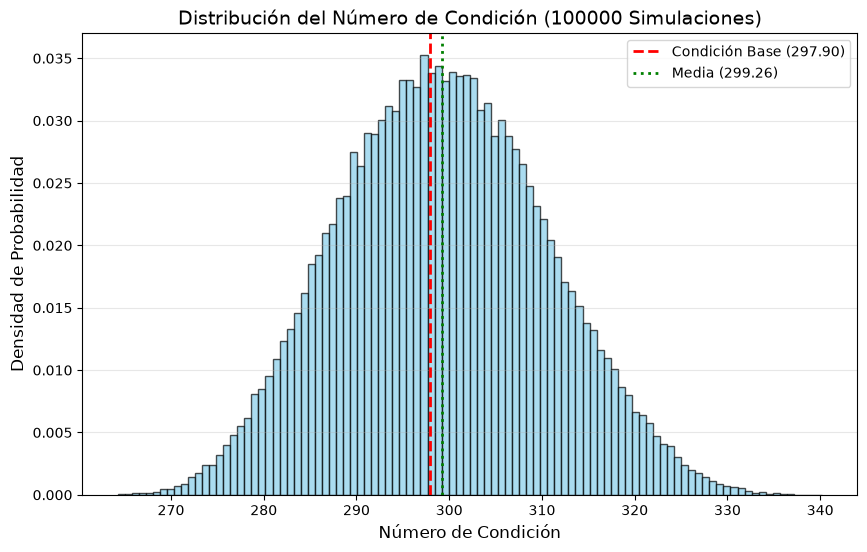

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Definición de Datos Iniciales ---
R = np.array([
    [1.00, 0.85, 0.75, 0.80, 0.60, 0.60, 0.30, 0.10, 0.40, 0.00, 0.00, 0.15, 0.10],
    [0.85, 1.00, 0.80, 0.65, 0.60, 0.60, 0.35, 0.15, 0.40, 0.00, 0.20, 0.10, 0.10],
    [0.75, 0.80, 1.00, 0.60, 0.60, 0.60, 0.40, 0.20, 0.40, -0.10, 0.00, 0.00, 0.00],
    [0.80, 0.65, 0.60, 1.00, 0.60, 0.60, 0.15, 0.10, 0.20, 0.00, 0.10, 0.10, 0.10],
    [0.60, 0.60, 0.60, 0.60, 1.00, 0.65, 0.10, 0.10, 0.20, 0.20, 0.20, 0.20, 0.10],
    [0.60, 0.60, 0.60, 0.60, 0.65, 1.00, 0.20, 0.10, 0.20, 0.10, 0.20, 0.20, 0.10],
    [0.30, 0.35, 0.40, 0.15, 0.10, 0.20, 1.00, 0.10, 0.00, 0.10, 0.10, 0.40, 0.00],
    [0.10, 0.15, 0.20, 0.10, 0.10, 0.10, 0.10, 1.00, 0.10, 0.00, 0.10, 0.00, 0.00],
    [0.40, 0.40, 0.40, 0.20, 0.20, 0.20, 0.00, 0.10, 1.00, 0.00, 0.20, 0.20, 0.00],
    [0.00, 0.00, -0.10, 0.00, 0.20, 0.10, 0.10, 0.00, 0.00, 1.00, 0.70, 0.60, 0.30],
    [0.00, 0.20, 0.00, 0.10, 0.20, 0.20, 0.10, 0.10, 0.20, 0.70, 1.00, 0.50, 0.30],
    [0.15, 0.10, 0.00, 0.10, 0.20, 0.20, 0.40, 0.00, 0.20, 0.60, 0.50, 1.00, 0.40],
    [0.10, 0.10, 0.00, 0.10, 0.10, 0.10, 0.00, 0.00, 0.00, 0.30, 0.30, 0.40, 1.00]
])

std_devs = np.array([0.155, 0.160, 0.180, 0.200, 0.110, 0.140, 0.210, 0.100, 0.150, 0.055, 0.058, 0.051, 0.035])

# --- 2. Parámetros de la Simulación ---
n_iterations = 100000  # Número de repeticiones (puedes cambiarlo a 1000, 10000 o 100000)
epsilon = 0.05          # Variación máxima del 5% (en términos relativos)

# Fijar semilla para reproducibilidad
np.random.seed(42)

# --- 3. Generación de Perturbaciones Aleatorias (Distribución Uniforme) ---
# Creamos un factor multiplicativo aleatorio entre (1 - epsilon) y (1 + epsilon) para cada iteración y cada activo
# El tamaño de la matriz de factores será (n_iterations, 13)
random_factors = np.random.uniform(1 - epsilon, 1 + epsilon, size=(n_iterations, len(std_devs)))
perturbed_std_devs = std_devs * random_factors

# --- 4. Cálculo Vectorizado de los Números de Condición ---
condition_numbers = []

for i in range(n_iterations):
    # Obtener el vector perturbado para esta iteración
    s = perturbed_std_devs[i]
    
    # Construir Sigma de forma eficiente: multiplicar filas y columnas usando 'broadcasting'
    # s[:, None] multiplica las filas, s[None, :] multiplica las columnas
    sigma_perturbed = R * s[:, None] * s[None, :]
    
    # Calcular número de condición y guardar
    cond = np.linalg.cond(sigma_perturbed)
    condition_numbers.append(cond)

condition_numbers = np.array(condition_numbers)

# --- 5. Análisis de Resultados Estadísticos ---
cond_base = np.linalg.cond(np.diag(std_devs) @ R @ np.diag(std_devs))

print("--- ESTADÍSTICAS DEL NÚMERO DE CONDICIÓN ---")
print(f"Valor Base Original : {cond_base:.4f}")
print(f"Mínimo Encontrado   : {np.min(condition_numbers):.4f}")
print(f"Máximo Encontrado   : {np.max(condition_numbers):.4f}")
print(f"Media (Promedio)    : {np.mean(condition_numbers):.4f}")
print(f"Mediana             : {np.median(condition_numbers):.4f}")
print(f"Desviación Estándar : {np.std(condition_numbers):.4f}")

# --- 6. Graficar la Distribución ---
plt.figure(figsize=(10, 6))
plt.hist(condition_numbers, bins=100, color='skyblue', edgecolor='black', alpha=0.7, density=True)
plt.axvline(cond_base, color='red', linestyle='dashed', linewidth=2, label=f'Condición Base ({cond_base:.2f})')
plt.axvline(np.mean(condition_numbers), color='green', linestyle=':', linewidth=2, label=f'Media ({np.mean(condition_numbers):.2f})')

plt.title(f'Distribución del Número de Condición ({n_iterations} Simulaciones)', fontsize=14)
plt.xlabel('Número de Condición', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()